## Soal: Kasus ML Diagnosa Diabetes dengan Unsupervised Learning (Clustering)

Dalam skenario ini, membuat simulasi data pasien dengan beberapa indikator terkait diabetes (misalnya, kadar Glukosa, Tekanan Darah, BMI, dan Insulin). Tujuan kita adalah menggunakan K-Means *Clustering* untuk secara otomatis mengelompokkan pasien-pasien ini ke dalam beberapa kelompok risiko diabetes (misalnya, Risiko Rendah, Risiko Sedang, Risiko Tinggi) tanpa label awal.

## 1. Simulasi Data Pasien Diabetes (misal: Glukosa, Tekanan Darah, IMT(Indeks Massa Tubuh), Insulin)


In [4]:
import joblib
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")


# Define the filename of the saved model
model_filename = 'diabetes_risk_model.joblib'

# Define features that the K-Means model expects
# This should match the features in new_patient_data
features_for_kmeans = ['Glukosa', 'Tekanan_Darah', 'IMT', 'Insulin', 'Usia']


try:
    # 1. Load the K-Means model
    loaded_kmeans_model = joblib.load(model_filename)
    print(f"Model K-Means berhasil dimuat dari: {model_filename}\n")
except FileNotFoundError:
    print(f"File model '{model_filename}' tidak ditemukan. Melakukan pelatihan dan penyimpanan model baru.")

    # Simulate training data for the K-Means model
    np.random.seed(42) # Different seed for training data simulation
    num_training_samples = 100
    training_data_diabetes_dict = {
        'Glukosa': np.random.randint(70, 250, num_training_samples),
        'Tekanan_Darah': np.random.randint(60, 180, num_training_samples),
        'IMT': np.random.uniform(16.0, 45.0, num_training_samples),
        'Insulin': np.random.randint(10, 400, num_training_samples),
        'Usia': np.random.randint(18, 80, num_training_samples)
    }
    df_training = pd.DataFrame(training_data_diabetes_dict)

    # Train a new K-Means model (e.g., with 3 clusters, similar to the first K-Means example)
    from sklearn.cluster import KMeans
    # Make sure n_init is set for KMeans in newer scikit-learn versions
    kmeans_trainer = KMeans(n_clusters=3, random_state=42, n_init=10)
    
    # Fit the model using the defined features
    kmeans_trainer.fit(df_training[features_for_kmeans])

    # Save the trained model
    joblib.dump(kmeans_trainer, model_filename)
    print(f"Model K-Means baru telah dilatih dan disimpan sebagai: {model_filename}\n")

    # Load the newly saved model to ensure `loaded_kmeans_model` is defined
    loaded_kmeans_model = joblib.load(model_filename)
    print(f"Model K-Means berhasil dimuat kembali dari: {model_filename}\n")




File model 'diabetes_risk_model.joblib' tidak ditemukan. Melakukan pelatihan dan penyimpanan model baru.
Model K-Means baru telah dilatih dan disimpan sebagai: diabetes_risk_model.joblib

Model K-Means berhasil dimuat kembali dari: diabetes_risk_model.joblib



## 3. Pengujian KMeans Clustering

In [8]:
# 2. Siapkan Data Pasien Baru (Simulasi)
# Pastikan fitur-fitur ini sesuai dengan yang digunakan saat melatih model

np.random.seed(50)
data_diabetes = {
    'Glukosa': np.random.randint(70, 180, 5), # Kadar glukosa puasa
    'Tekanan_Darah': np.random.randint(60, 150, 5), # Tekanan darah
    'IMT': np.random.uniform(15.0, 40.0, 5), # Indeks Massa Tubuh
    'Insulin': np.random.randint(15, 250, 5), # Kadar insulin
    'Usia': np.random.randint(30, 70, 5) # Usia pasien
}
new_patient_data = pd.DataFrame(data_diabetes)

print("Data Pasien Baru yang akan diprediksi:")
display(new_patient_data.head())

# 3. Gunakan model yang dimuat untuk memprediksi kluster untuk data pasien baru
# Ensure the new_patient_data passed to predict has the same feature columns as the training data
predicted_new_clusters = loaded_kmeans_model.predict(new_patient_data[features_for_kmeans])

# 4. Tampilkan Prediksi Kluster
print("\nPrediksi Kluster untuk Pasien Baru:")
for i, cluster in enumerate(predicted_new_clusters):
    print(f"Pasien Baru {i+1} diprediksi masuk Kluster ID: {cluster}")
# Create a mapping from Cluster_Risiko ID to a descriptive label

risk_mapping = {
    0: 'Risiko Rendah',
    1: 'Risiko Sedang',
    2: 'Risiko Tinggi'
}

# Opsional: Petakan Kluster ID ke Label Risiko yang bermakna
# Pastikan 'risk_mapping' dari langkah sebelumnya masih tersedia di lingkungan kernel
if 'risk_mapping' in globals():
    predicted_new_risk_labels = [risk_mapping[cluster_id] for cluster_id in predicted_new_clusters]
    print("\nPrediksi Label Risiko untuk Pasien Baru:")
    for i, label in enumerate(predicted_new_risk_labels):
        print(f"Pasien Baru {i+1} diprediksi memiliki: {label}")
else:
    print("\nVariabel 'risk_mapping' tidak tersedia untuk menerjemahkan kluster ke label risiko.")

Data Pasien Baru yang akan diprediksi:


,Glukosa,Tekanan_Darah,IMT,Insulin,Usia
0,118,64,35.117064,169,61
1,166,130,21.105752,233,51
2,81,130,23.129933,149,30
3,179,82,25.982626,163,36
4,103,65,18.369712,58,49



Prediksi Kluster untuk Pasien Baru:
Pasien Baru 1 diprediksi masuk Kluster ID: 0
Pasien Baru 2 diprediksi masuk Kluster ID: 0
Pasien Baru 3 diprediksi masuk Kluster ID: 0
Pasien Baru 4 diprediksi masuk Kluster ID: 0
Pasien Baru 5 diprediksi masuk Kluster ID: 1

Prediksi Label Risiko untuk Pasien Baru:
Pasien Baru 1 diprediksi memiliki: Risiko Rendah
Pasien Baru 2 diprediksi memiliki: Risiko Rendah
Pasien Baru 3 diprediksi memiliki: Risiko Rendah
Pasien Baru 4 diprediksi memiliki: Risiko Rendah
Pasien Baru 5 diprediksi memiliki: Risiko Sedang


## Hierarchical Clustering: Struktur Hubungan Gejala Pasien diabetes

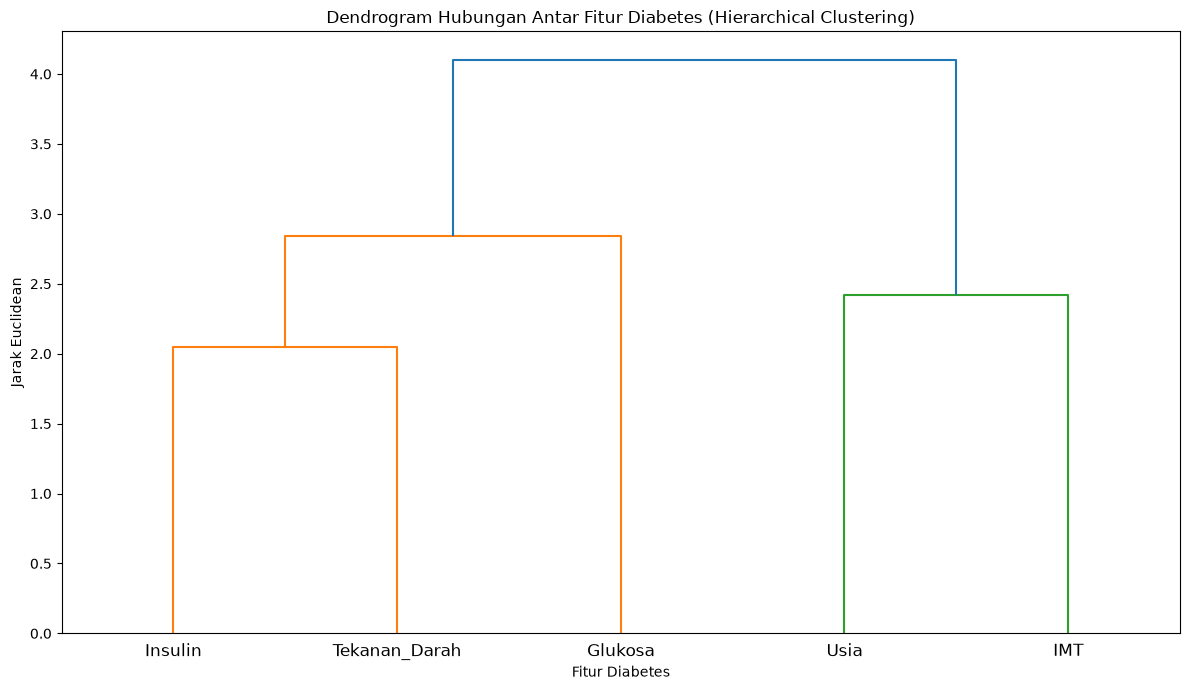

In [9]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Pilih fitur yang relevan dari new_patient_data
# Menggunakan 'Glukosa', 'Tekanan_Darah', 'IMT', 'Insulin', 'Usia' sebagai 'gejala'
features_for_hc = ['Glukosa', 'Tekanan_Darah', 'IMT', 'Insulin', 'Usia']
df_diabetes_features = new_patient_data[features_for_hc]

# 2. Standardisasi data fitur
# Penting untuk Hierarchical Clustering dengan data numerik untuk memberikan bobot yang sama pada setiap fitur
scaler_hc = StandardScaler()
df_scaled_hc = scaler_hc.fit_transform(df_diabetes_features)

# Konversi kembali ke DataFrame untuk mempertahankan nama fitur
df_scaled_hc = pd.DataFrame(df_scaled_hc, columns=features_for_hc)

# Untuk melakukan Hierarchical Clustering pada FEATURES, kita perlu mentranspose DataFrame
# sehingga fitur menjadi 'observasi' yang akan diklusterkan.
df_scaled_hc_transposed = df_scaled_hc.T

# 3. Lakukan Hierarchical Clustering pada fitur yang telah ditranspose
# Menggunakan 'euclidean' sebagai metrik jarak dan 'ward' sebagai metode linkage
linked_diabetes_features = linkage(df_scaled_hc_transposed, method='ward', metric='euclidean')

# 4. Visualisasikan Struktur Hubungan Gejala dengan Dendrogram
plt.figure(figsize=(12, 7))
dendrogram(
    linked_diabetes_features,
    orientation='top',
    labels=df_diabetes_features.columns, # Menggunakan nama fitur sebagai label
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Dendrogram Hubungan Antar Fitur Diabetes (Hierarchical Clustering)')
plt.xlabel('Fitur Diabetes')
plt.ylabel('Jarak Euclidean')
plt.tight_layout()
plt.show()